# Cross-National News Sentiment Analysis
### Greece x South Korea - Comparative Media Study

Scrapes and analyses headline sentiment from two news outlets:
- **To Vima** (Greece)
- **The Korea Herald** (South Korea)

**Pipeline:** Web Scraping -> Translation -> Sentiment (XLM-RoBERTa + VADER) -> Topic Modelling (BERTopic) -> Zero-Shot Classification -> NER -> Event Detection -> Framing & Readability -> Semantic Clustering


## 1. Setup & Imports

In [1]:
%pip install -q deep-translator vaderSentiment wordcloud plotly folium nltk scikit-learn
%pip install -q transformers torch bertopic sentence-transformers umap-learn hdbscan spacy textstat
import subprocess, sys
subprocess.run([sys.executable, '-m', 'spacy', 'download', 'en_core_web_sm', '--quiet'], check=True)
print('All packages ready')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.3/42.3 kB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.1/177.1 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 7.3 MB/s eta 0:00:00
All packages ready


In [2]:
import requests
import pandas as pd
import numpy as np
import re
import time
import warnings
import urllib.request
from collections import Counter
from bs4 import BeautifulSoup

from deep_translator import GoogleTranslator
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from transformers import pipeline as hf_pipeline

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.tag import pos_tag
from sklearn.feature_extraction.text import TfidfVectorizer

import spacy
import textstat
from scipy import stats

from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
import umap
import hdbscan

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from wordcloud import WordCloud
import folium

for resource in ['punkt', 'punkt_tab', 'averaged_perceptron_tagger_eng', 'stopwords']:
    nltk.download(resource, quiet=True)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')

HEADERS    = {'User-Agent': 'Mozilla/5.0 (compatible; academic-research-bot/1.0)'}
COLORS     = {'Greece': '#1f77b4', 'South Korea': '#e74c3c'}
STOP_WORDS = set(stopwords.words('english')) | {
    'said', 'say', 'says', 'also', 'one', 'two', 'new', 'year',
    'greek', 'greece', 'korea', 'korean', 'seoul',
}

print('All libraries loaded')

/usr/local/lib/python3.12/dist-packages/hdbscan/robust_single_linkage_.py:175: SyntaxWarning: invalid escape sequence '\{'
  $max \{ core_k(a), core_k(b), 1/\alpha d(a,b) \}$.


All libraries loaded


## 2. Web Scraping

### 2a. Greece - To Vima

Headlines are stored as image alt-text in Greek inside `<figure>` tags.
Each one is translated to English via Google Translate; the original Greek
is kept separately so XLM-RoBERTa can score it natively later.
Dates come from a `<time>` tag on the same page.


In [4]:
def scrape_tovima(url):

    soup = BeautifulSoup(requests.get(url, headers=HEADERS, timeout=10).text, 'html.parser')
    figures   = soup.find_all('figure', style=True)
    time_tags = soup.find_all('time', class_=re.compile('post-date'))

    rows = []
    for fig, t in zip(figures, time_tags):
        img        = fig.find('img')
        greek_text = img.get('alt', '').strip() if img else ''
        if not greek_text:
            continue
        try:
            english_text = GoogleTranslator(source='el', target='en').translate(greek_text)
        except Exception:
            english_text = greek_text
        rows.append({
            'Headline':          english_text,
            'Headline_Original': greek_text,
            'Date_Raw':          t.get_text(strip=True) if t else '',
            'Source':            'To Vima',
            'Country':           'Greece',
        })
    return pd.DataFrame(rows)


base      = 'https://www.tovima.gr/category/society/'
page_urls = [base] + [f'{base}page/{i}/' for i in range(2, 7)]

greek_news_df = pd.concat(
    [scrape_tovima(url) for url in page_urls],
    ignore_index=True
)
print(f'Greece: {len(greek_news_df)} articles scraped')
greek_news_df.head(3)

Greece: 112 articles scraped


,Headline,Headline_Original,Date_Raw,Source,Country
0,Inauguration of a new building of the School o...,Εγκαίνια νέου κτηρίου της Σχολής Οικονομικών κ...,"08.03.2026, 22:22",To Vima,Greece
1,Traffic arrangements on Attiki Odos: Which sec...,Κυκλοφοριακές ρυθμίσεις στην Αττική Οδό: Ποιο ...,"08.03.2026, 18:33",To Vima,Greece
2,"Golden Dawn: No leniency for the convicted, su...",Χρυσή Αυγή: Κανένα ελαφρυντικό στους καταδικασ...,"08.03.2026, 16:04",To Vima,Greece


### 2b. South Korea - Korea Herald

Article links match `/article/NNNNNNN`. The headline is the link text.
The date is a plain-text node inside the same `<li>` as the link.


In [5]:
def scrape_koreaherald(url):

    soup = BeautifulSoup(requests.get(url, headers=HEADERS, timeout=15).text, 'html.parser')
    date_pattern = re.compile(
        r'(January|February|March|April|May|June|July|August'
        r'|September|October|November|December)\s+\d{1,2},\s+\d{4}'
    )
    rows = []
    seen = set()

    for a in soup.find_all('a', href=re.compile(r'/article/\d+')):
        headline = a.get_text(strip=True)
        href     = a['href']
        if not href.startswith('http'):
            href = 'https://www.koreaherald.com' + href
        if len(headline) < 10 or href in seen:
            continue
        seen.add(href)

        date_str = ''
        parent   = a.find_parent('li')
        if parent:
            for text in parent.stripped_strings:
                if date_pattern.match(text):
                    date_str = text
                    break

        rows.append({
            'Headline':          headline,
            'Headline_Original': headline,
            'Date_Raw':          date_str,
            'Source':            'Korea Herald',
            'Country':           'South Korea',
        })
    return pd.DataFrame(rows)


base   = 'https://www.koreaherald.com/National'
frames = []
for page in range(1, 11):
    url = f'{base}?page={page}&pageTop=true#pagetop'
    try:
        frames.append(scrape_koreaherald(url))
    except Exception as e:
        print(f'Page {page} failed: {e}')
    time.sleep(0.5)

korea_news_df = pd.concat(frames, ignore_index=True)
korea_news_df = korea_news_df.drop_duplicates(subset=['Headline']).reset_index(drop=True)
print(f'South Korea: {len(korea_news_df)} articles scraped')
korea_news_df.head(3)

South Korea: 160 articles scraped


,Headline,Headline_Original,Date_Raw,Source,Country
0,$350b US investment bill set for passage Thurs...,$350b US investment bill set for passage Thurs...,,Korea Herald,South Korea
1,S. Korea launches new project to recover Korea...,S. Korea launches new project to recover Korea...,,Korea Herald,South Korea
2,Kim Jong-un projects 'socialist family' ideals...,Kim Jong-un projects 'socialist family' ideals...,,Korea Herald,South Korea


## 3. Data Cleaning

The two sources use different date formats:
- To Vima: `04.03.2026, 10:27`
- Korea Herald: `March 4, 2026`

Rows with dates that cannot be parsed are **kept** with `NaT` rather than dropped,
so they still appear in sentiment and topic analysis.


In [6]:
def parse_date(raw):

    if not isinstance(raw, str) or not raw.strip():
        return pd.NaT
    for fmt in [
        '%d.%m.%Y, %H:%M',
        '%B %d, %Y',
        '%Y-%m-%dT%H:%M:%S%z',
        '%Y-%m-%d',
    ]:
        try:
            ts = pd.to_datetime(raw.strip(), format=fmt)
            return ts.tz_localize(None) if ts.tzinfo else ts
        except (ValueError, TypeError):
            pass
    try:
        return pd.to_datetime(raw.strip(), utc=True).tz_localize(None)
    except Exception:
        return pd.NaT


def clean_df(df):
    """Deduplicate on headline, parse dates, sort chronologically."""
    df = df.dropna(subset=['Headline']).copy()
    df['Headline'] = df['Headline'].str.strip()
    df = df.drop_duplicates(subset=['Headline'])
    df['Date'] = df['Date_Raw'].apply(parse_date)
    df = df.sort_values('Date', na_position='last').reset_index(drop=True)
    print(f"  {df['Source'].iloc[0]}: {len(df)} articles, "
          f"{df['Date'].notna().sum()} with valid dates")
    return df


greek_news_df = clean_df(greek_news_df)
korea_news_df = clean_df(korea_news_df)
combined_df   = pd.concat([greek_news_df, korea_news_df], ignore_index=True)

print(f'Combined: {len(combined_df)} total articles')
combined_df.head(3)

  To Vima: 112 articles, 112 with valid dates
  Korea Herald: 160 articles, 147 with valid dates
Combined: 272 total articles


,Headline,Headline_Original,Date_Raw,Source,Country,Date
0,Three years since the tragedy in Tempe: Day of...,Τρία χρόνια από την τραγωδία στα Τέμπη: Ημέρα ...,"28.02.2026, 09:39",To Vima,Greece,2026-02-28 09:39:00
1,Alert before Easter: Fears of a new outbreak o...,Συναγερμός πριν το Πάσχα: Φόβοι για νέα έκρηξη...,"28.02.2026, 13:51",To Vima,Greece,2026-02-28 13:51:00
2,Aegean flights are canceled due to Iran - Whic...,Ακυρώνονται πτήσεις της Aegean λόγω Ιράν – Ποι...,"28.02.2026, 14:59",To Vima,Greece,2026-02-28 14:59:00


## 4. Sentiment Analysis - XLM-RoBERTa + VADER

Two methods are run and compared:
- **XLM-RoBERTa** scores each headline in its **original language** (Greek for To Vima,
  English for Korea Herald) - no translation needed.
- **VADER** scores the translated English headlines as a baseline.

Comparing both on the same translated text measures how much sentiment
is distorted by translation. XLM-RoBERTa is the primary signal used throughout.


In [7]:
print('Loading XLM-RoBERTa...')
xlm_pipe  = hf_pipeline(
    'sentiment-analysis',
    model='cardiffnlp/twitter-xlm-roberta-base-sentiment',
    max_length=128, truncation=True
)
LABEL_MAP = {'Positive': 1, 'Neutral': 0, 'Negative': -1}
vader     = SentimentIntensityAnalyzer()
print('Models ready')

Loading XLM-RoBERTa...


config.json:   0%|          | 0.00/841 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.11G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.11G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-xlm-roberta-base-sentiment
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

Models ready


In [8]:
def xlm_score(text):

    if not isinstance(text, str) or not text.strip():
        return pd.Series({'xlm_label': 'Unknown', 'xlm_compound': np.nan})
    result = xlm_pipe(text[:512])[0]
    label  = result['label'].capitalize()
    return pd.Series({
        'xlm_label':    label,
        'xlm_compound': result['score'] * LABEL_MAP.get(label, 0),
    })


def vader_score(text):
    """Return VADER compound score and label."""
    if not isinstance(text, str) or not text.strip():
        return pd.Series({'compound': np.nan, 'label': 'Unknown'})
    s     = vader.polarity_scores(text)
    label = 'Positive' if s['compound'] >= 0.05 else \
            'Negative' if s['compound'] <= -0.05 else 'Neutral'
    return pd.Series({'compound': s['compound'], 'label': label})


print('Running XLM-RoBERTa on original-language headlines...')
combined_df[['xlm_label', 'xlm_compound']] = \
    combined_df['Headline_Original'].apply(xlm_score)

print('Running VADER on translated English headlines...')
combined_df[['compound', 'label']] = \
    combined_df['Headline'].apply(vader_score)

agree_pct = (combined_df['xlm_label'] == combined_df['label']).mean() * 100
print(f'Done  |  XLM-RoBERTa vs VADER agreement: {agree_pct:.1f}%')
combined_df.groupby('Country')[['xlm_compound', 'compound']].mean().round(3)

Running XLM-RoBERTa on original-language headlines...
Running VADER on translated English headlines...
Done  |  XLM-RoBERTa vs VADER agreement: 48.5%


,xlm_compound,compound
Country,,
Greece,-0.304,-0.261
South Korea,-0.239,0.089


In [9]:
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=('XLM-RoBERTa - native language', 'VADER - translated English')
)
for col, score_col in enumerate(['xlm_compound', 'compound'], 1):
    for country, grp in combined_df.groupby('Country'):
        fig.add_trace(go.Violin(
            x=grp[score_col].dropna(), name=country,
            line_color=COLORS[country], fillcolor=COLORS[country],
            opacity=0.5, box_visible=True, meanline_visible=True,
            orientation='h', showlegend=(col == 1)
        ), row=1, col=col)
fig.update_layout(
    title='Sentiment Method Comparison: Transformer vs Rule-Based',
    height=400, template='plotly_white'
)
fig.show()

## 5. Exploratory Data Analysis

### 5a. Sentiment Distribution

In [10]:
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=('Score Distribution', 'Category Breakdown (%)')
)
palette = {'Positive': '#2ecc71', 'Neutral': '#95a5a6', 'Negative': '#e74c3c'}

for country, grp in combined_df.groupby('Country'):
    fig.add_trace(go.Violin(
        x=grp['xlm_compound'], name=country,
        line_color=COLORS[country], fillcolor=COLORS[country],
        opacity=0.6, box_visible=True, meanline_visible=True, orientation='h'
    ), row=1, col=1)

cat_pct = combined_df.groupby(['Country', 'xlm_label']).size().reset_index(name='n')
cat_pct['pct'] = cat_pct['n'] / cat_pct.groupby('Country')['n'].transform('sum') * 100
for lbl, grp in cat_pct.groupby('xlm_label'):
    fig.add_trace(go.Bar(
        x=grp['Country'], y=grp['pct'], name=lbl,
        marker_color=palette.get(lbl, 'grey')
    ), row=1, col=2)

fig.update_layout(
    title='Headline Sentiment (XLM-RoBERTa): Greece vs South Korea',
    barmode='stack', height=440, template='plotly_white'
)
fig.show()

### 5b. Sentiment Over Time

In [11]:
time_df = combined_df.dropna(subset=['Date', 'xlm_compound']).copy()

if time_df.empty:
    print('No dated articles - check date parsing.')
else:
    weekly = (
        time_df.set_index('Date')
        .groupby('Country')['xlm_compound']
        .resample('W').mean()
        .reset_index()
        .rename(columns={'xlm_compound': 'Mean_Sentiment', 'Date': 'Week'})
    )
    fig = px.line(
        weekly, x='Week', y='Mean_Sentiment', color='Country',
        color_discrete_map=COLORS, markers=True,
        title='Weekly Average Sentiment (XLM-RoBERTa)',
        template='plotly_white'
    )
    fig.add_hline(y=0, line_dash='dash', line_color='grey', annotation_text='Neutral')
    fig.show()

### 5c. Sentiment Heatmap by Day of Week

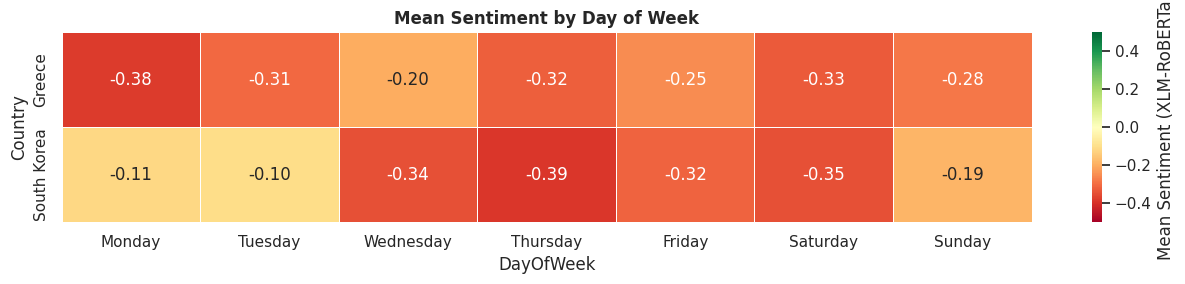

In [12]:
dow_df = combined_df.dropna(subset=['Date']).copy()
dow_df['DayOfWeek'] = dow_df['Date'].dt.day_name()

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
pivot = dow_df.pivot_table(
    values='xlm_compound', index='Country', columns='DayOfWeek', aggfunc='mean'
).reindex(columns=[d for d in day_order if d in dow_df['DayOfWeek'].unique()])

fig, ax = plt.subplots(figsize=(13, 3))
sns.heatmap(
    pivot, annot=True, fmt='.2f', cmap='RdYlGn',
    center=0, vmin=-0.5, vmax=0.5, linewidths=0.5, ax=ax,
    cbar_kws={'label': 'Mean Sentiment (XLM-RoBERTa)'}
)
ax.set_title('Mean Sentiment by Day of Week', fontweight='bold')
plt.tight_layout()
plt.show()

### 5d. Top Positive & Negative Headlines

In [13]:
for country in ['Greece', 'South Korea']:
    sub = combined_df[combined_df['Country'] == country].dropna(subset=['xlm_compound'])
    print(f'\n{"=" * 60}')
    print(f'{country} - Most Positive')
    for _, r in sub.nlargest(5, 'xlm_compound').iterrows():
        print(f'  [{r["xlm_compound"]:+.3f}]  {r["Headline"][:85]}')
    print(f'{country} - Most Negative')
    for _, r in sub.nsmallest(5, 'xlm_compound').iterrows():
        print(f'  [{r["xlm_compound"]:+.3f}]  {r["Headline"][:85]}')


Greece - Most Positive
  [+0.698]  Women's Day: Big march with "Violanda" workers, paints at the Ministry of Labor
  [+0.590]  Piraeus: The Piraeus Makerspace brings the circular economy into practice
  [+0.531]  Magda Fyssa: I will not see them again, peace has won
  [+0.493]  Tempe: Black anniversary with rallies around the world - Episodes, special reports
  [+0.463]  'Enjoy the bloody viewing': Terror victims rage over Koufodina interview
Greece - Most Negative
  [-0.817]  Concern about fuel and food – Increased demand and new waves of price appreciation du
  [-0.816]  War in Iran: Fears of a "rally" in fuel - Queues at gas stations, stocks empty
  [-0.803]  Taurus: A large fire in an apartment, an unconscious 50-year-old man was rescued
  [-0.796]  A 4.4 Richter earthquake "shook" Kastellorizo
  [-0.788]  Ioannina: Subsidence "swallowed" the municipality's cleaning vehicle

South Korea - Most Positive
  [+0.701]  Top 100 Global InnovatorsPablo Air aims higher with AI drone swarms

### 5e. Geographic Sentiment Map

In [14]:
country_coords = {
    'Greece':      {'lat': 38.2, 'lon':  23.7},
    'South Korea': {'lat': 37.5, 'lon': 127.0},
}
m = folium.Map(location=[45, 70], zoom_start=2, tiles='CartoDB positron')

for country, coords in country_coords.items():
    avg   = combined_df[combined_df['Country'] == country]['xlm_compound'].mean()
    count = (combined_df['Country'] == country).sum()
    color = '#2ecc71' if avg > 0.05 else '#e74c3c' if avg < -0.05 else '#f39c12'
    folium.CircleMarker(
        location=[coords['lat'], coords['lon']],
        radius=max(15, abs(avg) * 80),
        color=color, fill=True, fill_color=color, fill_opacity=0.65,
        tooltip=f"{country}: {avg:+.3f} ({count} articles)"
    ).add_to(m)
m

## 6. Topic Modelling - BERTopic

BERTopic uses sentence embeddings rather than raw word counts, so headlines
with similar *meaning* cluster together even if they use different words.
Topics are labelled automatically with their most distinctive keywords.


In [15]:
print('Embedding headlines...')
embed_model = SentenceTransformer('all-MiniLM-L6-v2')
headlines   = combined_df['Headline'].fillna('').tolist()
embeddings  = embed_model.encode(headlines, show_progress_bar=True, batch_size=64)

print('Fitting BERTopic...')
topic_model = BERTopic(embedding_model=embed_model, min_topic_size=5,
                       nr_topics='auto', verbose=False)
topics, _   = topic_model.fit_transform(headlines, embeddings)
combined_df['BERTopic'] = topics

n_topics = len([t for t in set(topics) if t != -1])
print(f'Topics found: {n_topics}  |  Outliers (topic -1): {topics.count(-1)}')
topic_model.get_topic_info().head(12)

Embedding headlines...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/5 [00:00<?, ?it/s]

Fitting BERTopic...
Topics found: 5  |  Outliers (topic -1): 60


,Topic,Count,Name,Representation,Representative_Docs
0,-1,60,-1_the_of_to_in,"[the, of, to, in, and, korea, 2026, for, as, on]",[Human or mechanical error? Family challenges ...
1,0,117,0_the_to_of_in,"[the, to, of, in, and, on, korea, 2026, from, ...",[Chartered plane to bring home S. Koreans from...
2,1,55,1_in_the_was_old,"[in, the, was, old, year, are, war, student, d...","[Iran War: Trapped in Dubai, the testimony of ..."
3,2,20,2_the_of_prosecutor_tempi,"[the, of, prosecutor, tempi, what, dawn, golde...",[Golden Dawn: The hour of the verdict – From t...
4,3,12,3_the_of_indicted_to,"[the, of, indicted, to, police, in, accused, f...",[Man indicted for forging $4m in bank checks t...
5,4,8,4_colonos_31_old_pregnant,"[colonos, 31, old, pregnant, year, woman, was,...",[The partner of the 31-year-old woman who was ...


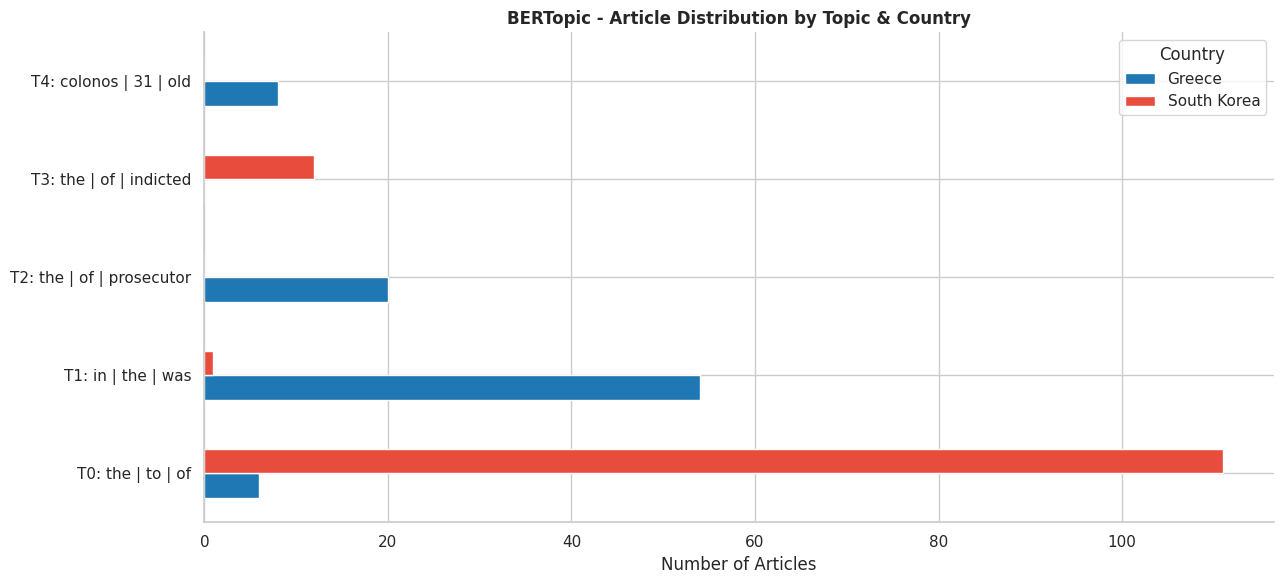

In [16]:
topic_info   = topic_model.get_topic_info()
topic_labels = {
    row['Topic']: ' | '.join(w for w, _ in topic_model.get_topic(row['Topic'])[:3])
    for _, row in topic_info[topic_info['Topic'] != -1].iterrows()
}

topic_country = (
    combined_df[combined_df['BERTopic'] != -1]
    .groupby(['BERTopic', 'Country']).size().unstack(fill_value=0)
    .assign(Total=lambda d: d.sum(axis=1))
    .sort_values('Total', ascending=False).head(15)
)
topic_country.index = [
    f"T{i}: {topic_labels.get(i, '')[:30]}" for i in topic_country.index
]

fig, ax = plt.subplots(figsize=(13, 6))
topic_country[['Greece', 'South Korea']].plot(
    kind='barh', ax=ax,
    color=[COLORS['Greece'], COLORS['South Korea']], edgecolor='white'
)
ax.set_title('BERTopic - Article Distribution by Topic & Country', fontweight='bold')
ax.set_xlabel('Number of Articles')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

In [17]:
# Interactive BERTopic charts (best viewed in a live Jupyter environment)
topic_model.visualize_topics().show()
topic_model.visualize_heatmap().show()

### 6a. TF-IDF Distinctive Terms & Word Clouds

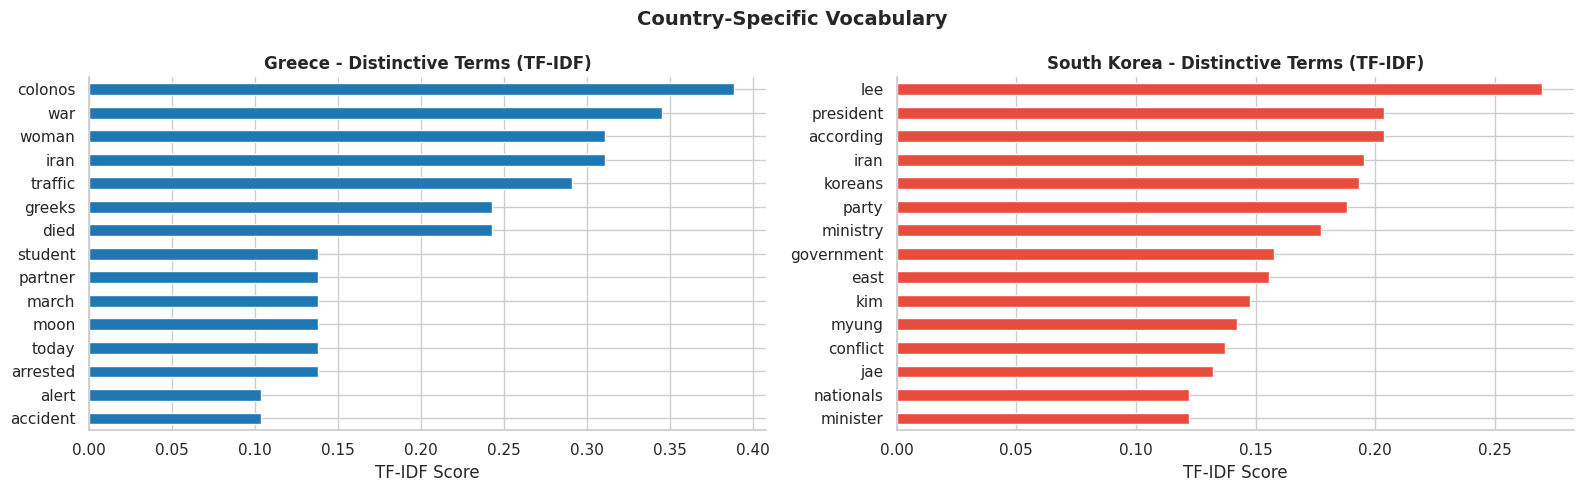

In [18]:
def content_words(text):
    if not isinstance(text, str):
        return ''
    tokens = word_tokenize(text.lower())
    tagged = pos_tag(tokens)
    return ' '.join(
        w for w, t in tagged
        if t.startswith(('NN', 'VB')) and w.isalpha()
        and w not in STOP_WORDS and len(w) > 2
    )

combined_df['Tokens'] = combined_df['Headline'].apply(content_words)

# Each country treated as one document; TF-IDF scores terms by how
# distinctive they are to that country vs the other
country_docs = [
    ' '.join(combined_df[combined_df['Country'] == c]['Tokens'].dropna())
    for c in ['Greece', 'South Korea']
]
tfidf  = TfidfVectorizer(max_features=300, stop_words='english')
matrix = tfidf.fit_transform(country_docs)
vocab  = tfidf.get_feature_names_out()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for i, (country, ax) in enumerate(zip(['Greece', 'South Korea'], axes)):
    scores = pd.Series(matrix[i].toarray().flatten(), index=vocab).nlargest(15).sort_values()
    scores.plot(kind='barh', ax=ax, color=list(COLORS.values())[i], edgecolor='white')
    ax.set_title(f'{country} - Distinctive Terms (TF-IDF)', fontweight='bold')
    ax.set_xlabel('TF-IDF Score')
    ax.spines[['top', 'right']].set_visible(False)
plt.suptitle('Country-Specific Vocabulary', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

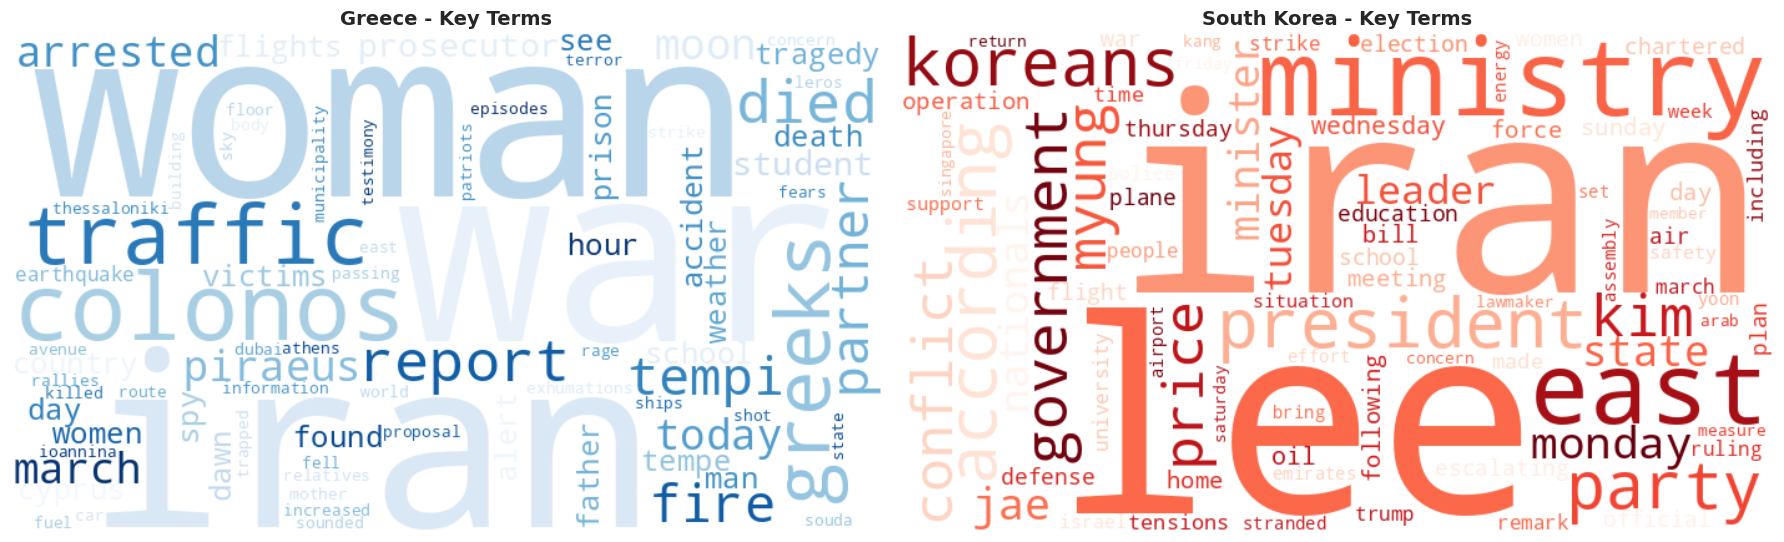

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
for ax, (country, cmap) in zip(axes, [('Greece', 'Blues'), ('South Korea', 'Reds')]):
    text = ' '.join(combined_df[combined_df['Country'] == country]['Tokens'].dropna())
    wc   = WordCloud(width=700, height=400, background_color='white',
                     colormap=cmap, max_words=80, collocations=False).generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(f'{country} - Key Terms', fontsize=14, fontweight='bold')
    ax.axis('off')
plt.tight_layout()
plt.show()

## 7. Zero-Shot Topic Classification

Headlines are assigned to one of eight thematic categories **without any labelled
training data**. The model frames each assignment as a natural language inference
task: *does this headline entail topic X?*

A small, CPU-friendly model (`cross-encoder/nli-MiniLM2-L6-H768`) is used
and headlines are sent in batches of 16 to keep runtime manageable.


In [20]:
print('Loading zero-shot classifier...')
zero_shot = hf_pipeline(
    'zero-shot-classification',
    model='cross-encoder/nli-MiniLM2-L6-H768',
    device=-1
)
CATEGORIES = [
    'politics and government', 'crime and justice',
    'economy and business',    'health and medicine',
    'military and security',   'society and culture',
    'environment and disaster','international relations',
]
print('Ready')

Loading zero-shot classifier...


config.json:   0%|          | 0.00/875 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/328M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cross-encoder/nli-MiniLM2-L6-H768
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

Ready


In [21]:
BATCH_SIZE    = 16
all_headlines = combined_df['Headline'].fillna('').tolist()
labels        = []

print(f'Classifying {len(all_headlines)} headlines in batches of {BATCH_SIZE}...')

for i in range(0, len(all_headlines), BATCH_SIZE):
    batch = all_headlines[i : i + BATCH_SIZE]
    try:
        results = zero_shot(batch, CATEGORIES, multi_label=False)
        if isinstance(results, dict):
            results = [results]  # single-item batch returns a dict, not a list
        labels.extend(r['labels'][0] for r in results)
    except Exception:
        labels.extend(['unknown'] * len(batch))

    done = min(i + BATCH_SIZE, len(all_headlines))
    if done % 100 == 0 or done == len(all_headlines):
        print(f'  ... {done}/{len(all_headlines)} done')

combined_df['ZS_Category'] = labels
print('Done')
combined_df.groupby(['Country', 'ZS_Category']).size().unstack(fill_value=0)

Classifying 272 headlines in batches of 16...
  ... 272/272 done
Done


ZS_Category,crime and justice,economy and business,environment and disaster,health and medicine,international relations,military and security,politics and government,society and culture
Country,,,,,,,,
Greece,17,7,20,3,11,20,5,29
South Korea,12,11,0,9,44,37,31,16


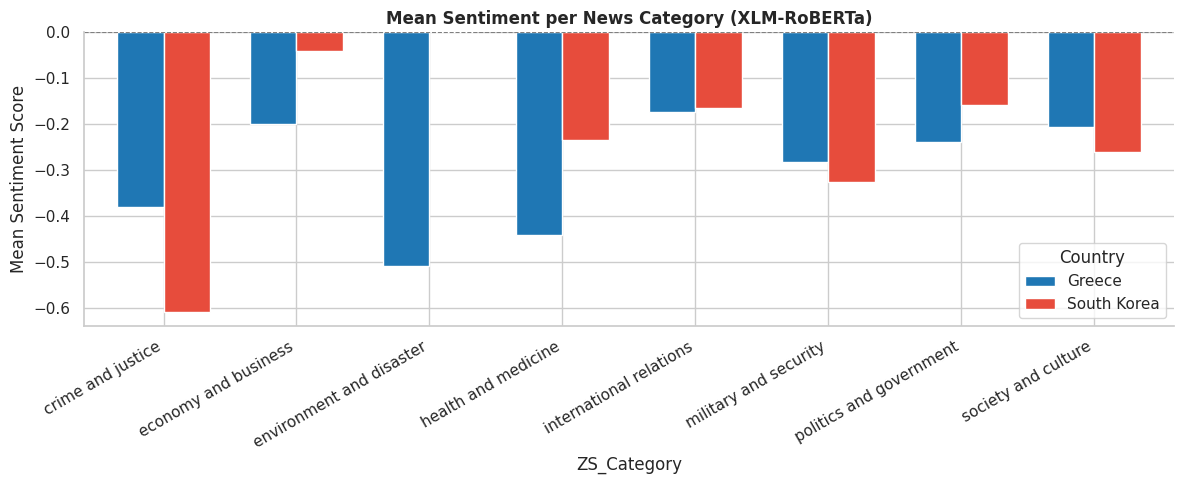

In [22]:
cat_pct = (
    combined_df[combined_df['ZS_Category'] != 'unknown']
    .groupby(['Country', 'ZS_Category']).size()
    .reset_index(name='Count')
)
cat_pct['Pct'] = cat_pct['Count'] / cat_pct.groupby('Country')['Count'].transform('sum') * 100

px.bar(
    cat_pct, x='ZS_Category', y='Pct', color='Country',
    color_discrete_map=COLORS, barmode='group',
    title='Zero-Shot Topic Classification: Greece vs South Korea',
    labels={'Pct': '% of Articles', 'ZS_Category': 'Category'},
    template='plotly_white', height=460
).update_layout(xaxis_tickangle=-25).show()

cat_sentiment = (
    combined_df[combined_df['ZS_Category'] != 'unknown']
    .groupby(['Country', 'ZS_Category'])['xlm_compound']
    .mean().unstack(level=0)
)
fig2, ax = plt.subplots(figsize=(12, 5))
cat_sentiment.plot(
    kind='bar', ax=ax,
    color=[COLORS['Greece'], COLORS['South Korea']],
    edgecolor='white', width=0.7
)
ax.axhline(0, color='grey', linestyle='--', linewidth=0.8)
ax.set_title('Mean Sentiment per News Category (XLM-RoBERTa)', fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
ax.set_ylabel('Mean Sentiment Score')
ax.spines[['top', 'right']].set_visible(False)
ax.legend(title='Country')
plt.tight_layout()
plt.show()

## 8. Named Entity Recognition (NER)

spaCy identifies people, organisations, and locations in each headline.
Comparing entity frequency between the two outlets reveals what - and who -
each country's news agenda focuses on.


In [23]:
nlp = spacy.load('en_core_web_sm')

ENTITY_TYPES = {
    'PERSON': 'People',
    'ORG':    'Organisations',
    'GPE':    'Countries / Cities',
    'NORP':   'Nationalities / Groups',
}

ner_results = {}
for country in ['Greece', 'South Korea']:
    texts    = combined_df[combined_df['Country'] == country]['Headline'].dropna().tolist()
    entities = []
    for doc in nlp.pipe(texts, batch_size=64):
        for ent in doc.ents:
            if ent.label_ in ENTITY_TYPES:
                entities.append((ent.text.strip(), ent.label_))
    ner_results[country] = entities
    print(f'  {country}: {len(entities)} entity mentions')


def top_entities(entity_list, label, n=12):
    filtered = [text for text, lbl in entity_list if lbl == label]
    return pd.DataFrame(Counter(filtered).most_common(n), columns=['Entity', 'Count'])

print('NER complete')

  Greece: 88 entity mentions
  South Korea: 1167 entity mentions
NER complete


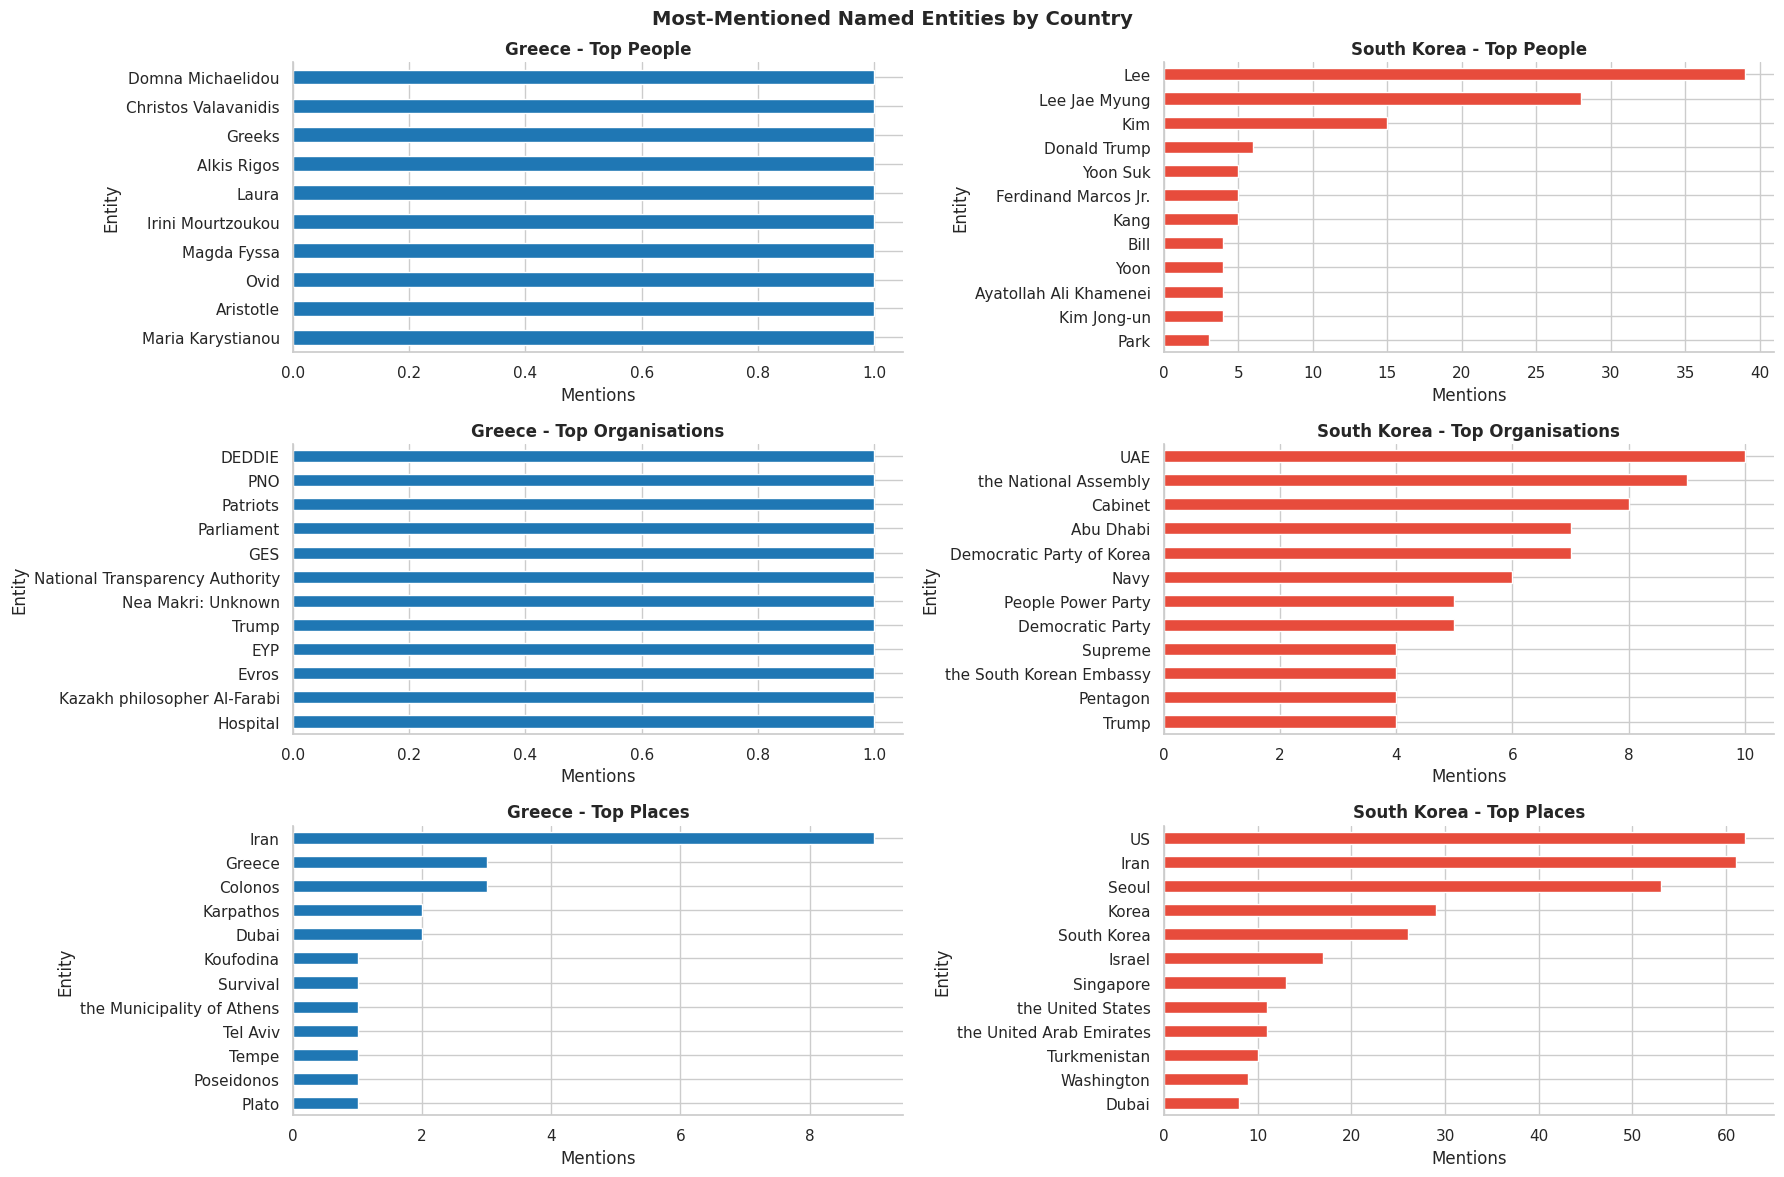

Shared entities (mentioned by both outlets):
  People: none
  Organisations: International Women's Day, Trump
  Places: Dubai, Germany, Iran, Tel Aviv


In [24]:
PLOT_TYPES = [('PERSON', 'People'), ('ORG', 'Organisations'), ('GPE', 'Places')]
fig, axes  = plt.subplots(len(PLOT_TYPES), 2, figsize=(18, len(PLOT_TYPES) * 4))

for row, (label, title) in enumerate(PLOT_TYPES):
    for col, country in enumerate(['Greece', 'South Korea']):
        ax   = axes[row, col]
        df_e = top_entities(ner_results[country], label)
        if df_e.empty:
            ax.axis('off')
            continue
        df_e.sort_values('Count').plot(
            kind='barh', x='Entity', y='Count',
            ax=ax, color=COLORS[country], edgecolor='white', legend=False
        )
        ax.set_title(f'{country} - Top {title}', fontweight='bold')
        ax.set_xlabel('Mentions')
        ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('Most-Mentioned Named Entities by Country', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('Shared entities (mentioned by both outlets):')
for label, title in PLOT_TYPES:
    gr     = {t for t, l in ner_results['Greece']      if l == label}
    kr     = {t for t, l in ner_results['South Korea'] if l == label}
    shared = sorted(gr & kr)
    print(f'  {title}: {", ".join(shared[:10]) or "none"}')

## 9. Event Detection via Sentiment Spikes

A z-score above 1.5 flags days where sentiment deviated unusually from that
country's own baseline. Z-scores are computed per country separately so
differences in baseline tone do not inflate one country's spike count.


In [25]:
dated_df = combined_df.dropna(subset=['Date', 'xlm_compound']).copy()
dated_df['Day'] = dated_df['Date'].dt.normalize()

daily = (
    dated_df.groupby(['Country', 'Day'])
    .agg(Mean_Sentiment=('xlm_compound', 'mean'), Article_Count=('Headline', 'count'))
    .reset_index()
)

spike_rows = []
for country, grp in daily.groupby('Country'):
    grp = grp.sort_values('Day').copy()
    if len(grp) >= 4:
        z = stats.zscore(grp['Mean_Sentiment'], nan_policy='omit')
        grp['Spike'] = np.abs(z) > 1.5
    else:
        grp['Spike'] = False
    spike_rows.append(grp)

daily = pd.concat(spike_rows, ignore_index=True)
print(f'Spike days detected: {daily["Spike"].sum()}')
print(daily[daily['Spike']][['Country', 'Day', 'Mean_Sentiment', 'Article_Count']])

Spike days detected: 2
       Country        Day  Mean_Sentiment  Article_Count
7       Greece 2026-03-07       -0.479316              7
9  South Korea 2026-03-02       -0.007997              7


In [26]:
fig = go.Figure()
for country in ['Greece', 'South Korea']:
    grp    = daily[daily['Country'] == country].sort_values('Day')
    spikes = grp[grp['Spike']]

    fig.add_trace(go.Scatter(
        x=grp['Day'], y=grp['Mean_Sentiment'],
        mode='lines+markers', name=country,
        line=dict(color=COLORS[country], width=2)
    ))
    if not spikes.empty:
        fig.add_trace(go.Scatter(
            x=spikes['Day'], y=spikes['Mean_Sentiment'],
            mode='markers', name=f'{country} spike',
            marker=dict(color=COLORS[country], size=14, symbol='star')
        ))
        for _, row in spikes.iterrows():
            fig.add_annotation(
                x=row['Day'], y=row['Mean_Sentiment'],
                text=row['Day'].strftime('%b %d'),
                showarrow=True, arrowhead=2, ax=0, ay=-30,
                font=dict(size=9, color=COLORS[country])
            )

fig.add_hline(y=0, line_dash='dash', line_color='grey')
fig.update_layout(title='Daily Sentiment with Detected Spikes',
                  template='plotly_white', height=460)
fig.show()

In [28]:
for _, spike in daily[daily['Spike']].iterrows():
    mask          = (dated_df['Country'] == spike['Country']) & (dated_df['Day'] == spike['Day'])
    day_headlines = dated_df[mask].sort_values('xlm_compound')
    print(f"\n[{spike['Country']}]  {spike['Day'].strftime('%A %b %d')}  "
          f"(avg: {spike['Mean_Sentiment']:+.3f})")
    for _, r in day_headlines.head(3).iterrows():
        print(f"  [{r['xlm_compound']:+.3f}]  {r['Headline'][:85]}")


[Greece]  Saturday Mar 07  (avg: -0.479)
  [-0.744]  Tripoli: A police officer was shot dead in her apartment
  [-0.736]  The distinguished journalist Giorgos Votsis has died
  [-0.688]  EODY: The entire scientific council resigned

[South Korea]  Monday Mar 02  (avg: -0.008)
  [-0.509]  PM asks gov't to stay prepared against 'every possible scenario' in Middle East confl
  [+0.000]  Lee taps 4-term ruling party lawmaker to head Budget MinistryPresident Lee Jae Myung 
  [+0.000]  Dominican Republic marks Independence Day in SeoulThe Dominican Republic marked the 1


## 10. Framing & Readability Analysis

The **NRC Emotion Lexicon** maps words to 8 emotions (anger, fear, joy, trust, etc.),
revealing the emotional palette of each outlet beyond positive/negative.
**Readability metrics** measure writing complexity, indicating the assumed reading
level of each audience.


In [29]:
NRC_URL = 'https://raw.githubusercontent.com/dinbav/LeXmo/master/NRC-Emotion-Lexicon-Wordlevel-v0.92.txt'
urllib.request.urlretrieve(NRC_URL, 'nrc_lexicon.txt')

NRC_EMOTIONS = ['fear', 'anger', 'trust', 'surprise', 'sadness', 'disgust', 'joy', 'anticipation']
nrc = {}
with open('nrc_lexicon.txt', encoding='utf-8') as f:
    for line in f:
        parts = line.strip().split('\t')
        if len(parts) == 3:
            word, emotion, flag = parts
            if emotion in NRC_EMOTIONS and flag == '1':
                nrc.setdefault(word, set()).add(emotion)
print(f'NRC lexicon: {len(nrc):,} words loaded')

NRC lexicon: 4,463 words loaded


In [30]:
def nrc_emotions(text):
    """Return emotion scores as fractions of total emotion-bearing words."""
    if not isinstance(text, str):
        return {e: 0.0 for e in NRC_EMOTIONS}
    words  = re.findall(r'[a-z]+', text.lower())
    counts = Counter(e for w in words if w in nrc for e in nrc[w])
    total  = sum(counts.values()) or 1
    return {e: counts.get(e, 0) / total for e in NRC_EMOTIONS}


combined_df[NRC_EMOTIONS] = combined_df['Headline'].apply(
    lambda t: pd.Series(nrc_emotions(t))
)
combined_df['FK_Grade']     = combined_df['Headline'].apply(
    lambda t: textstat.flesch_kincaid_grade(t) if isinstance(t, str) else np.nan
)
combined_df['Avg_Word_Len'] = combined_df['Headline'].apply(
    lambda t: np.mean([len(w) for w in t.split()]) if isinstance(t, str) else np.nan
)
combined_df['Headline_Len'] = combined_df['Headline'].apply(
    lambda t: len(t.split()) if isinstance(t, str) else np.nan
)
print(combined_df.groupby('Country')[['FK_Grade', 'Avg_Word_Len', 'Headline_Len']].mean().round(2))

             FK_Grade  Avg_Word_Len  Headline_Len
Country                                          
Greece           7.96          5.15         12.13
South Korea     15.29          5.46         83.40


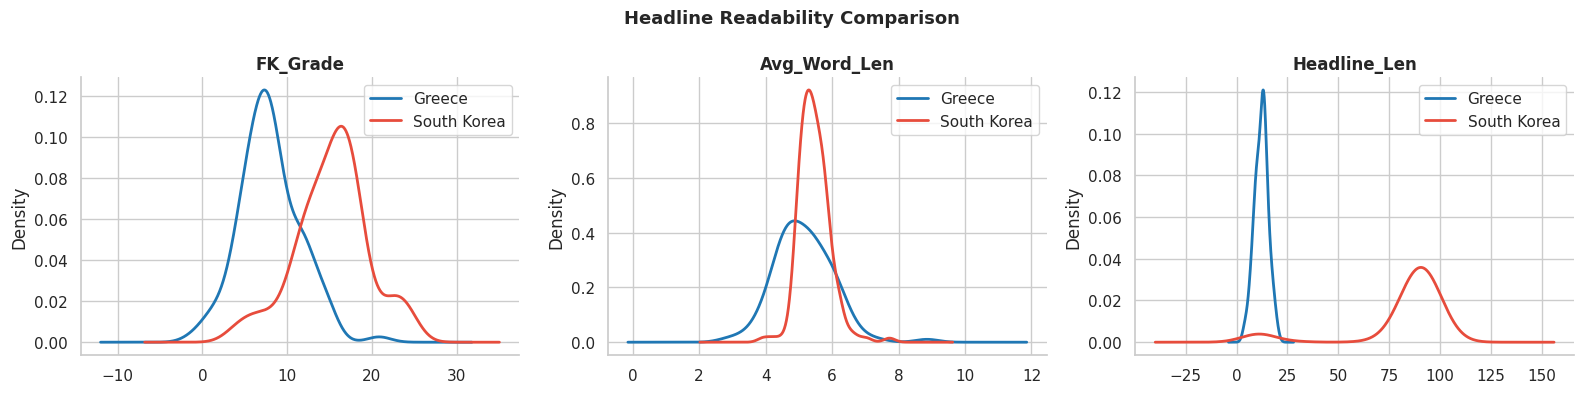

In [31]:
# Emotion radar chart
means = combined_df.groupby('Country')[NRC_EMOTIONS].mean()
fig   = go.Figure()
for country in ['Greece', 'South Korea']:
    vals = means.loc[country].tolist()
    fig.add_trace(go.Scatterpolar(
        r=vals + [vals[0]], theta=NRC_EMOTIONS + [NRC_EMOTIONS[0]],
        fill='toself', name=country,
        line_color=COLORS[country], fillcolor=COLORS[country], opacity=0.35
    ))
fig.update_layout(title='NRC Emotion Profile: Greece vs South Korea',
                  template='plotly_white', height=500)
fig.show()

# Emotion bar chart
emotion_long = means.reset_index().melt(id_vars='Country', var_name='Emotion', value_name='Score')
px.bar(emotion_long, x='Emotion', y='Score', color='Country',
       color_discrete_map=COLORS, barmode='group',
       title='Mean NRC Emotion Scores by Country',
       template='plotly_white').show()

# Readability KDE curves
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, ['FK_Grade', 'Avg_Word_Len', 'Headline_Len']):
    for country in ['Greece', 'South Korea']:
        combined_df[combined_df['Country'] == country][col].dropna().plot(
            kind='kde', ax=ax, label=country, color=COLORS[country], linewidth=2
        )
    ax.set_title(col, fontweight='bold')
    ax.legend()
    ax.spines[['top', 'right']].set_visible(False)
plt.suptitle('Headline Readability Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 11. Semantic Clustering - UMAP + HDBSCAN

Headlines are embedded using the same sentence transformer as BERTopic.
UMAP reduces the embeddings to 2D for visualisation, then HDBSCAN finds
density-based clusters. Clusters containing headlines from both countries
reveal stories that both outlets covered independently.


In [32]:
sem_df = combined_df[['Headline', 'Country', 'xlm_compound', 'xlm_label']].dropna(
    subset=['Headline']
).copy().reset_index(drop=True)

print(f'Embedding {len(sem_df)} headlines...')
model      = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = model.encode(sem_df['Headline'].tolist(), show_progress_bar=True, batch_size=64)

print('Running UMAP...')
coords = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.05,
                   metric='cosine', random_state=42).fit_transform(embeddings)
sem_df[['UMAP_x', 'UMAP_y']] = coords

print('Running HDBSCAN...')
sem_df['Cluster'] = hdbscan.HDBSCAN(
    min_cluster_size=6, min_samples=3, metric='euclidean'
).fit_predict(coords)

n_noise = (sem_df['Cluster'] == -1).sum()
print(f'Clusters found: {sem_df["Cluster"].nunique() - 1}  |  Noise points: {n_noise}')

Embedding 272 headlines...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/5 [00:00<?, ?it/s]

Running UMAP...
Running HDBSCAN...
Clusters found: 15  |  Noise points: 59


In [33]:
plot_df = sem_df.copy()
plot_df['Cluster_Label']  = plot_df['Cluster'].apply(lambda c: f'Cluster {c}' if c >= 0 else 'Noise')
plot_df['Headline_Short'] = plot_df['Headline'].str[:80] + '...'

px.scatter(
    plot_df, x='UMAP_x', y='UMAP_y',
    color='Country', symbol='Cluster_Label',
    color_discrete_map=COLORS, opacity=0.75,
    hover_data={'Headline_Short': True, 'xlm_compound': ':.3f',
                'Cluster_Label': True, 'UMAP_x': False, 'UMAP_y': False},
    title='Semantic Map of Headlines (UMAP + HDBSCAN)',
    labels={'UMAP_x': 'UMAP Dim 1', 'UMAP_y': 'UMAP Dim 2'},
    template='plotly_white', height=580
).show()

In [34]:
cluster_comp = (
    sem_df[sem_df['Cluster'] >= 0]
    .groupby(['Cluster', 'Country']).size().unstack(fill_value=0)
    .assign(Total=lambda d: d.sum(axis=1))
    .sort_values('Total', ascending=False)
)

def cluster_keywords(cluster_id, n=5):
    words = ' '.join(sem_df[sem_df['Cluster'] == cluster_id]['Headline']).lower().split()
    top   = [w for w, _ in Counter(
        w for w in words if w.isalpha() and w not in STOP_WORDS and len(w) > 3
    ).most_common(n)]
    return ', '.join(top)

print(f"{'Cluster':>8}  {'Greece':>7}  {'S.Korea':>8}  {'Total':>6}  Keywords")
print('-' * 70)
for cid, row in cluster_comp.head(10).iterrows():
    gr   = row.get('Greece', 0)
    kr   = row.get('South Korea', 0)
    flag = 'shared' if gr > 0 and kr > 0 else '      '
    print(f"{flag}  {cid:>4}  {gr:>7}  {kr:>8}  {row['Total']:>6}  {cluster_keywords(cid)}")

 Cluster   Greece   S.Korea   Total  Keywords
----------------------------------------------------------------------
shared     2       31         1      32  dead, woman, pregnant, student, died
           4       29         0      29  greeks, traffic, iran, flights, trapped
           1       21         0      21  country, golden, rallies, world, victims
shared    11        2        19      21  south, middle, koreans, chartered, ministry
          14        0        17      17  middle, east, south, minister, situation
           8        0        14      14  president, south, myung, singapore, summit
           6        0        13      13  party, ruling, local, democratic, national
shared    13        1        11      12  middle, prices, price, east, fuel
           0        0        10      10  trump, iran, military, operation, israel
          12        0         9       9  crash, according, force, south, accident


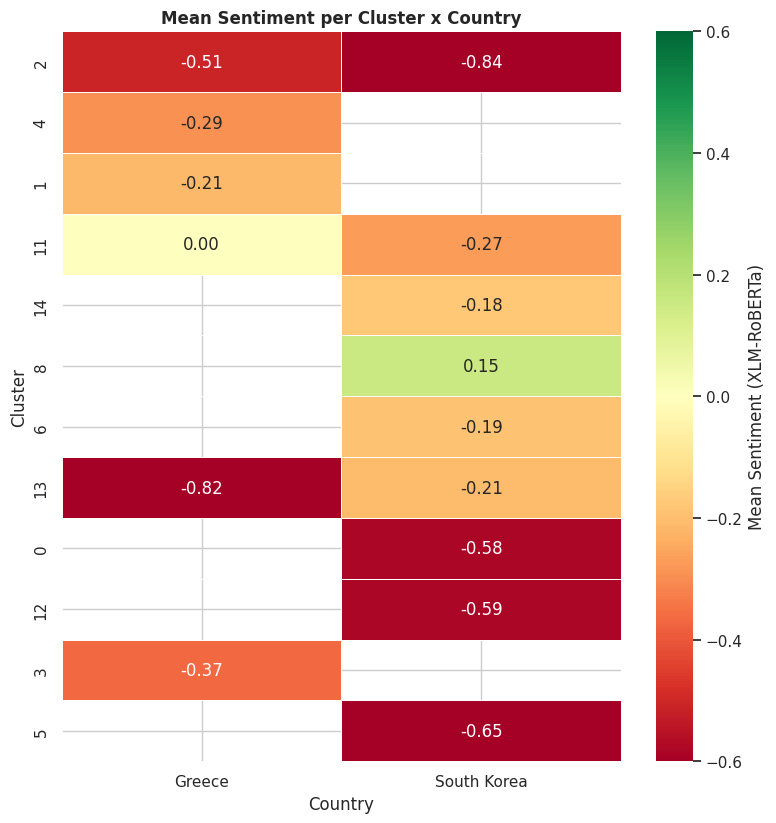

In [35]:
cluster_sent = (
    sem_df[sem_df['Cluster'] >= 0]
    .groupby(['Cluster', 'Country'])['xlm_compound'].mean()
    .unstack(fill_value=np.nan)
    .loc[cluster_comp.head(12).index]
)
fig, ax = plt.subplots(figsize=(8, max(4, len(cluster_sent) * 0.7)))
sns.heatmap(
    cluster_sent, annot=True, fmt='.2f', cmap='RdYlGn',
    center=0, vmin=-0.6, vmax=0.6, linewidths=0.5, ax=ax,
    cbar_kws={'label': 'Mean Sentiment (XLM-RoBERTa)'}
)
ax.set_title('Mean Sentiment per Cluster x Country', fontweight='bold')
plt.tight_layout()
plt.show()

## 13. Save Results

In [ ]:
combined_df.to_csv('news_sentiment_combined.csv', index=False)
greek_news_df.to_csv('greek_news_clean.csv',       index=False)
korea_news_df.to_csv('korea_news_clean.csv',       index=False)
try:
    sem_df.to_csv('semantic_clusters.csv', index=False)
except NameError:
    pass
print(f'Saved — combined shape: {combined_df.shape}')
print(f'Columns: {list(combined_df.columns)}')